<a href="https://colab.research.google.com/github/Nandhini0226/agricultural-production-pattern-clustering/blob/main/agricultural_production_pattern_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Required Libraries**

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [83]:
# GitHub Raw URL
url = "https://raw.githubusercontent.com/Nandhini0226/agricultural-production-pattern-clustering/main/paddydataset.csv"

# Load dataset
df = pd.read_csv(url)

# **Initial Data Inspection**

In [84]:
# First 5 Records
print("\nFirst 5 Rows:")
display(df.head())


First 5 Rows:


,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


In [85]:
# Dataset Shape
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(2789, 45)


In [86]:
# Column Names
print("\nColumn Names:")
print(df.columns.tolist())


Column Names:
['Hectares ', 'Agriblock', 'Variety', 'Soil Types', 'Seedrate(in Kg)', 'LP_Mainfield(in Tonnes)', 'Nursery', 'Nursery area (Cents)', 'LP_nurseryarea(in Tonnes)', 'DAP_20days', 'Weed28D_thiobencarb', 'Urea_40Days', 'Potassh_50Days', 'Micronutrients_70Days', 'Pest_60Day(in ml)', '30DRain( in mm)', '30DAI(in mm)', '30_50DRain( in mm)', '30_50DAI(in mm)', '51_70DRain(in mm)', '51_70AI(in mm)', '71_105DRain(in mm)', '71_105DAI(in mm)', 'Min temp_D1_D30', 'Max temp_D1_D30', 'Min temp_D31_D60', 'Max temp_D31_D60', 'Min temp_D61_D90', 'Max temp_D61_D90', 'Min temp_D91_D120', 'Max temp_D91_D120', 'Inst Wind Speed_D1_D30(in Knots)', 'Inst Wind Speed_D31_D60(in Knots)', 'Inst Wind Speed_D61_D90(in Knots)', 'Inst Wind Speed_D91_D120(in Knots)', 'Wind Direction_D1_D30', 'Wind Direction_D31_D60', 'Wind Direction_D61_D90', 'Wind Direction_D91_D120', 'Relative Humidity_D1_D30', 'Relative Humidity_D31_D60', 'Relative Humidity_D61_D90', 'Relative Humidity_D91_D120', 'Trash(in bundles)', '

In [87]:
# Dataset Information
print("\nDataset Information:")
df.info()



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2789 entries, 0 to 2788
Data columns (total 45 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Hectares                            2789 non-null   int64  
 1   Agriblock                           2789 non-null   object 
 2   Variety                             2789 non-null   object 
 3   Soil Types                          2789 non-null   object 
 4   Seedrate(in Kg)                     2789 non-null   int64  
 5   LP_Mainfield(in Tonnes)             2789 non-null   float64
 6   Nursery                             2789 non-null   object 
 7   Nursery area (Cents)                2789 non-null   int64  
 8   LP_nurseryarea(in Tonnes)           2789 non-null   int64  
 9   DAP_20days                          2789 non-null   int64  
 10  Weed28D_thiobencarb                 2789 non-null   int64  
 11  Urea_40Days          

In [88]:
# Data Types
print("\nData Types:")
print(df.dtypes)



Data Types:
Hectares                                int64
Agriblock                              object
Variety                                object
Soil Types                             object
Seedrate(in Kg)                         int64
LP_Mainfield(in Tonnes)               float64
Nursery                                object
Nursery area (Cents)                    int64
LP_nurseryarea(in Tonnes)               int64
DAP_20days                              int64
Weed28D_thiobencarb                     int64
Urea_40Days                           float64
Potassh_50Days                        float64
Micronutrients_70Days                   int64
Pest_60Day(in ml)                       int64
30DRain( in mm)                       float64
30DAI(in mm)                          float64
30_50DRain( in mm)                    float64
30_50DAI(in mm)                       float64
51_70DRain(in mm)                     float64
51_70AI(in mm)                        float64
71_105DRain(in mm)   

In [89]:
# Duplicate Records
print("\nDuplicate Rows:")
print(df.duplicated().sum())


Duplicate Rows:
451


In [90]:
# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Hectares                              0
Agriblock                             0
Variety                               0
Soil Types                            0
Seedrate(in Kg)                       0
LP_Mainfield(in Tonnes)               0
Nursery                               0
Nursery area (Cents)                  0
LP_nurseryarea(in Tonnes)             0
DAP_20days                            0
Weed28D_thiobencarb                   0
Urea_40Days                           0
Potassh_50Days                        0
Micronutrients_70Days                 0
Pest_60Day(in ml)                     0
30DRain( in mm)                       0
30DAI(in mm)                          0
30_50DRain( in mm)                    0
30_50DAI(in mm)                       0
51_70DRain(in mm)                     0
51_70AI(in mm)                        0
71_105DRain(in mm)                    0
71_105DAI(in mm)                      0
Min temp_D1_D30                       0
Max temp_D1_D30        

In [91]:
# Statistical Summary Including Categorical Columns
print("\nComplete Summary:")
display(df.describe(include='all'))


Complete Summary:


,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
count,2789.000000,2789,2789,2789,2789.000000,2789.000000,2789,2789.000000,2789.000000,2789.000000,...,2789,2789,2789,2789,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000
unique,NaN,6,3,2,NaN,NaN,2,NaN,NaN,NaN,...,6,5,5,6,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Sankarapuram,ponmani,clay,NaN,NaN,dry,NaN,NaN,NaN,...,SSE,W,SE,NW,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,605,1061,1521,NaN,NaN,1540,NaN,NaN,NaN,...,605,1055,899,605,NaN,NaN,NaN,NaN,NaN,NaN
mean,3.717461,NaN,NaN,NaN,92.936536,46.468268,NaN,74.349229,3.717461,148.698458,...,NaN,NaN,NaN,NaN,76.256938,87.594120,85.160272,83.859448,335.510936,22517.728935
std,1.437777,NaN,NaN,NaN,35.944420,17.972210,NaN,28.755536,1.437777,57.511072,...,NaN,NaN,NaN,NaN,8.001361,6.776736,3.492529,3.134875,134.314772,9199.661393
min,1.000000,NaN,NaN,NaN,25.000000,12.500000,NaN,20.000000,1.000000,40.000000,...,NaN,NaN,NaN,NaN,64.600000,78.000000,81.000000,79.000000,80.000000,5410.000000
25%,3.000000,NaN,NaN,NaN,75.000000,37.500000,NaN,60.000000,3.000000,120.000000,...,NaN,NaN,NaN,NaN,72.000000,80.000000,83.000000,81.000000,240.000000,16389.000000
50%,4.000000,NaN,NaN,NaN,100.000000,50.000000,NaN,80.000000,4.000000,160.000000,...,NaN,NaN,NaN,NaN,72.700000,91.000000,84.000000,84.000000,360.000000,24636.000000
75%,5.000000,NaN,NaN,NaN,125.000000,62.500000,NaN,100.000000,5.000000,200.000000,...,NaN,NaN,NaN,NaN,85.000000,95.000000,88.000000,87.000000,450.000000,31035.000000


# **Data Cleaning and Transformation**

**Remove Duplicate Records**

In [92]:
# Remove duplicate rows
df = df.drop_duplicates()

**Verify Categorical Values**

In [93]:
# Duplicate Records
print("\nDuplicate Rows:")
print(df.duplicated().sum())


Duplicate Rows:
0


In [94]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


Agriblock
['Cuddalore' 'Kurinjipadi' 'Panruti' 'Kallakurichi' 'Sankarapuram'
 'Chinnasalem']

Variety
['CO_43' 'ponmani' 'delux ponni']

Soil Types
['alluvial' 'clay']

Nursery
['dry' 'wet']

Wind Direction_D1_D30
['SW' 'NW' 'ENE' 'W' 'SSE' 'E']

Wind Direction_D31_D60
['W' 'S' 'NE' 'WNW' 'ENE']

Wind Direction_D61_D90
['NNW' 'SE' 'NNE' 'SW' 'NE']

Wind Direction_D91_D120
['WSW' 'SSE' 'W' 'S' 'NW' 'NNW']


**Convert Numerical Columns to Float**

In [95]:
# Select numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Convert all numerical columns to float
df[numerical_cols] = df[numerical_cols].astype(float)

# Verify
df[numerical_cols].dtypes

,0
Hectares,float64
Seedrate(in Kg),float64
LP_Mainfield(in Tonnes),float64
Nursery area (Cents),float64
LP_nurseryarea(in Tonnes),float64
DAP_20days,float64
Weed28D_thiobencarb,float64
Urea_40Days,float64
Potassh_50Days,float64
Micronutrients_70Days,float64


# **Data Preprocessing**

**Separate Target Variable**

In [96]:
# Store yield separately
yield_data = df["Paddy yield(in Kg)"]

# Remove yield from clustering dataset
X = df.drop(columns=["Paddy yield(in Kg)"])

**Identify Feature Types**

In [97]:
# Numerical columns
numerical_cols = X.select_dtypes(include='number').columns.tolist()

# Categorical columns
categorical_cols = X.select_dtypes(include='object').columns.tolist()



**Feature Scaling and Encoding**

In [98]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="drop"
)
#Apply preprocessing
X_processed = preprocessor.fit_transform(X)

In [99]:
print(type(X_processed))
print(X_processed.shape)

<class 'numpy.ndarray'>
(2338, 71)


# **Determine Optimal Number of Clusters**

**Elbow Method**

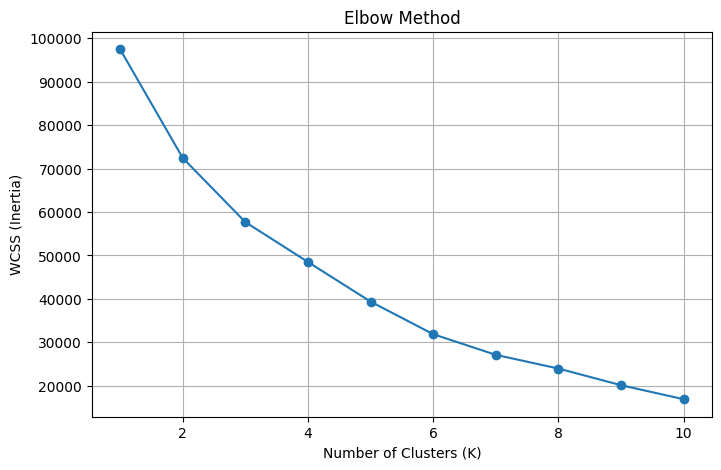

In [100]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_processed)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.grid(True)
plt.show()

**Silhouette Analysis**

In [101]:
silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_processed)

    score = silhouette_score(X_processed, labels)

    silhouette_scores.append(score)

    print(f"K = {k}  --> Silhouette Score = {score:.4f}")

K = 2  --> Silhouette Score = 0.2742
K = 3  --> Silhouette Score = 0.3155
K = 4  --> Silhouette Score = 0.3665
K = 5  --> Silhouette Score = 0.3700
K = 6  --> Silhouette Score = 0.4592
K = 7  --> Silhouette Score = 0.4469
K = 8  --> Silhouette Score = 0.4524
K = 9  --> Silhouette Score = 0.4694
K = 10  --> Silhouette Score = 0.4794


**Model Selection**

The optimal number of clusters was selected as K = 3 based on the Elbow Method. Although the Silhouette Score continued to increase for larger values of K, the improvement was gradual and did not exhibit a distinct optimum. Therefore, K = 3 was chosen to achieve a balance between model simplicity and interpretability."

# **Build the K-Means Clustering Model**

In [102]:
# Train K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Predict cluster labels
df["Cluster"] = kmeans.fit_predict(X_processed)

**Cluster Distribution**

In [103]:
df["Cluster"].value_counts().sort_index()

,count
Cluster,
0,765
1,711
2,862


# **Cluster Performance Analysis**

**Paddy Yield Analysis**

In [104]:
df.groupby("Cluster")["Paddy yield(in Kg)"].agg(
    Count="count",
    Average_Yield="mean",
    Min_Yield="min",
    Max_Yield="max"
)

,Count,Average_Yield,Min_Yield,Max_Yield
Cluster,,,,
0,765,22591.162092,5410.0,38814.0
1,711,22468.059072,5410.0,38508.0
2,862,22744.113689,5410.0,38814.0



**Numerical Feature Analysis**

In [105]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True).round(2)

cluster_summary.T

Cluster,0,1,2
Hectares,3.74,3.71,3.75
Seedrate(in Kg),93.46,92.86,93.79
LP_Mainfield(in Tonnes),46.73,46.43,46.90
Nursery area (Cents),74.77,74.29,75.03
LP_nurseryarea(in Tonnes),3.74,3.71,3.75
DAP_20days,149.54,148.58,150.07
Weed28D_thiobencarb,7.48,7.43,7.50
Urea_40Days,101.43,100.77,101.78
Potassh_50Days,38.81,38.56,38.94
Micronutrients_70Days,56.08,55.72,56.28


**Categorical Feature Analysis**

In [106]:
# Soil type distribution
pd.crosstab(df["Cluster"], df["Soil Types"], normalize="index") * 100


Soil Types,alluvial,clay
Cluster,,
0,44.444444,55.555556
1,49.367089,50.632911
2,43.967517,56.032483


In [107]:
# Variety distribution
pd.crosstab(df["Cluster"], df["Variety"], normalize="index") * 100


Variety,CO_43,delux ponni,ponmani
Cluster,,,
0,25.228758,36.470588,38.300654
1,25.175809,32.911392,41.912799
2,27.726218,37.006961,35.266821


In [108]:
# Nursery distribution
pd.crosstab(df["Cluster"], df["Nursery"], normalize="index") * 100

Nursery,dry,wet
Cluster,,
0,53.986928,46.013072
1,53.305204,46.694796
2,53.712297,46.287703


In [109]:

# Agriblock distribution
pd.crosstab(df["Cluster"], df["Agriblock"], normalize="index") * 100

Agriblock,Chinnasalem,Cuddalore,Kallakurichi,Kurinjipadi,Panruti,Sankarapuram
Cluster,,,,,,
0,0.000000,47.581699,0.000000,52.418301,0.000000,0.000000
1,50.351617,0.000000,49.648383,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,41.763341,58.236659
